# Analyse non supervisée
## Clusterisation multi algorithmes

Nous menons plusieurs expériences avec **différents algorithmes de clusterisation** : 
- KMeans
- GMM
- DBScan

2026/01/12 09:40:50 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet




Données labellisées: (100, 2048)
Labels: (100,)

Réduction de dimensionnalité avec PCA...
Variance expliquée (50 composantes): 90.49%

Utilisation de PCA uniquement

=== CLUSTERING KMeans ===
Score ARI (données labellisées): 0.636
Répartition clusters unlabeled: [468 938]


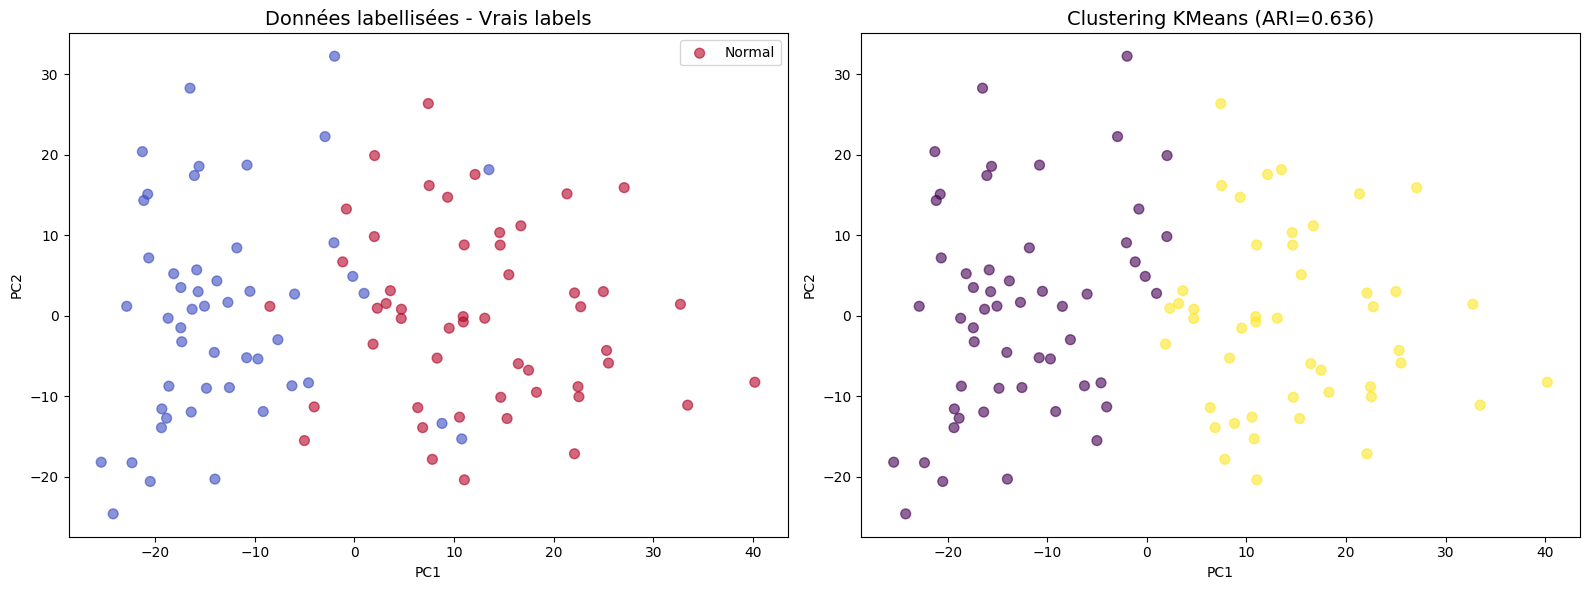

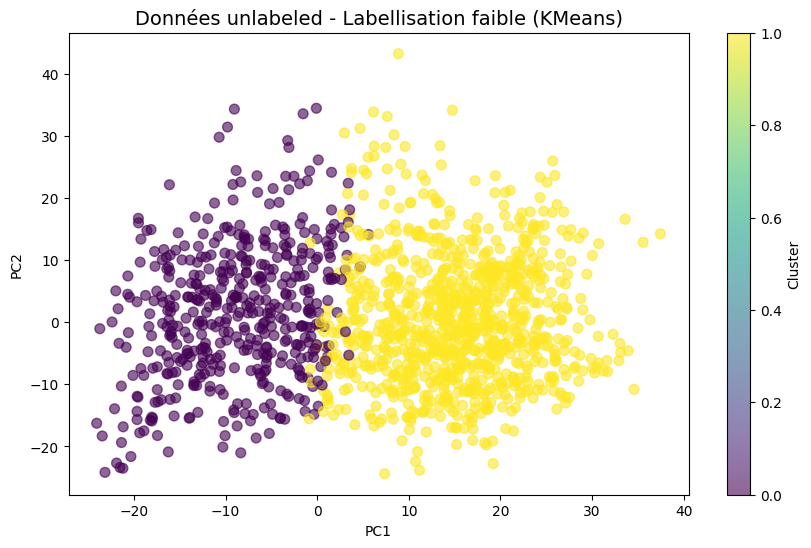

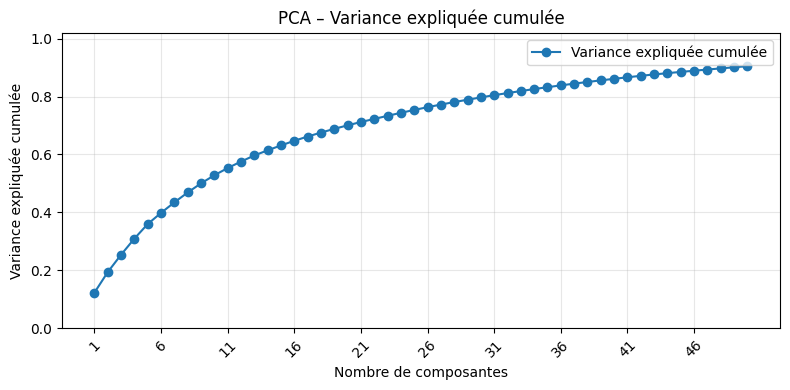

2026/01/12 09:40:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run fortunate-ape-315 at: http://mlflow:5000/#/experiments/458238933919020479/runs/a64a03790dba4ca29b34d955e35ac32a
🧪 View experiment at: http://mlflow:5000/#/experiments/458238933919020479


In [1]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from pathlib import Path
from constants import CANCER, NORMAL, DATA_DIR, PREPARED_DIR, FEATURES_DIR, WITHOUT_LABEL, WITH_LABEL, WEAK_LABELS
from visualization import plot_labeled_comparison, plot_unlabeled_clusters

RANDOM_STATE = 42
N_COMPONENTS_PCA = 50
USE_TSNE = False
N_CLUSTERS = 2

# ============================================
# CONFIGURATION CLUSTERING
# ============================================
ALGORITHM = "KMeans"  # "KMeans" ou "GMM" ou "DBSCAN"

# (Optionnel) paramètres DBSCAN ici
DBSCAN_EPS = 0.5
DBSCAN_MIN_SAMPLES = 5

# Dictionnaire des modèles et leurs paramètres spécifiques
MODELS = {
    "KMeans": {
        "class": KMeans,
        "params": {"n_clusters": N_CLUSTERS, "random_state": RANDOM_STATE, "n_init": 10}
    },
    "GMM": {
        "class": GaussianMixture,
        "params": {"n_components": N_CLUSTERS, "random_state": RANDOM_STATE, "covariance_type": "full"}
    },
    "DBSCAN": {
        "class": DBSCAN,
        "params": {"eps": DBSCAN_EPS, "min_samples": DBSCAN_MIN_SAMPLES}
    }
}

# Instanciation dynamique
config = MODELS[ALGORITHM]
model = config["class"](**config["params"])

# ============================================
# CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================

# Chargement des features
features_cancer = np.load(FEATURES_DIR / "features_cancer_avgpool.npy")
features_normal = np.load(FEATURES_DIR / "features_normal_avgpool.npy")
features_unlabeled = np.load(FEATURES_DIR / "features_unlabeled_avgpool.npy")

# Préparation des données labelisées (pour évaluation ARI)
X_labeled = np.vstack([features_cancer, features_normal])
y_true = np.array([1]*len(features_cancer) + [0]*len(features_normal))

print(f"\nDonnées labellisées: {X_labeled.shape}")
print(f"Labels: {y_true.shape}")

mlflow.set_experiment(f"clustering-{ALGORITHM.lower()}")

with mlflow.start_run():
    mlflow.log_param("n_components_pca", N_COMPONENTS_PCA)
    mlflow.log_param("use_tsne", USE_TSNE)
    mlflow.log_param("cluster_algo", ALGORITHM)
    mlflow.log_param("n_clusters", N_CLUSTERS)

    # Log params spécifiques DBSCAN (optionnel mais utile)
    if ALGORITHM == "DBSCAN":
        mlflow.log_param("dbscan_eps", DBSCAN_EPS)
        mlflow.log_param("dbscan_min_samples", DBSCAN_MIN_SAMPLES)

    # Standardisation des features
    scaler = StandardScaler()
    X_labeled_scaled = scaler.fit_transform(X_labeled)
    X_unlabeled_scaled = scaler.transform(features_unlabeled)
    
    # Réduction de dimensionnalité avec PCA
    print("\nRéduction de dimensionnalité avec PCA...")
    pca = PCA(n_components=N_COMPONENTS_PCA)
    X_labeled_pca = pca.fit_transform(X_labeled_scaled)
    X_unlabeled_pca = pca.transform(X_unlabeled_scaled)
    
    print(f"Variance expliquée ({N_COMPONENTS_PCA} composantes): {pca.explained_variance_ratio_.sum():.2%}")
    
    # Appliquer la réduction TSNE ?
    if USE_TSNE:
        print("\nApplication de t-SNE sur l'ensemble des données...")
        X_all_pca = np.vstack([X_labeled_pca, X_unlabeled_pca])
        tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca')
        X_all_reduced = tsne.fit_transform(X_all_pca)
        X_labeled_reduced = X_all_reduced[:len(X_labeled_pca)]
        X_unlabeled_reduced = X_all_reduced[len(X_labeled_pca):]
        print(" t-SNE appliqué sur un espace commun")
    else:
        print("\nUtilisation de PCA uniquement")
        X_labeled_reduced = X_labeled_pca
        X_unlabeled_reduced = X_unlabeled_pca
    
    # PCA 2D pour visualisation
    pca_2d = PCA(n_components=2)
    X_labeled_pca_2d = pca_2d.fit_transform(X_labeled_scaled)
    X_unlabeled_pca_2d = pca_2d.transform(X_unlabeled_scaled)
    
    # ============================================
    # CLUSTERING
    # ============================================
    print(f"\n=== CLUSTERING {ALGORITHM} ===")
    
    # Clustering sur données labellisées (pour évaluation)
    y_pred_labeled = model.fit_predict(X_labeled_reduced)
    ari_score = adjusted_rand_score(y_true, y_pred_labeled)
    print(f"Score ARI (données labellisées): {ari_score:.3f}")
    
    # Clustering sur données unlabeled (labellisation faible)
    if ALGORITHM == "DBSCAN":
        # DBSCAN n'a pas de predict() en sklearn -> on refit sur unlabeled
        y_pred_unlabeled = model.fit_predict(X_unlabeled_reduced)
    else:
        y_pred_unlabeled = model.predict(X_unlabeled_reduced)

    print(f"Répartition clusters unlabeled: {np.bincount(y_pred_unlabeled[y_pred_unlabeled >= 0])}")
    if ALGORITHM == "DBSCAN":
        print(f"Nombre de points bruit (label -1): {(y_pred_unlabeled == -1).sum()}")
    
    # ============================================
    # VISUALISATIONS + LOG MLFLOW
    # ============================================
    
    fig_labeled = plot_labeled_comparison(
        X_labeled_pca_2d, 
        y_true, 
        y_pred_labeled, 
        ALGORITHM, 
        ari_score
    )
    mlflow.log_figure(fig_labeled, "cluster_labeled.png")
    plt.show()
    plt.close(fig_labeled)
    
    fig_unlabeled = plot_unlabeled_clusters(
        X_unlabeled_pca_2d, 
        y_pred_unlabeled, 
        ALGORITHM
    )
    mlflow.log_figure(fig_unlabeled, "cluster_unlabeled.png")
    plt.show()
    plt.close(fig_unlabeled)

    # --- Courbe d'éboulis PCA (variance expliquée cumulée uniquement) ---
    cum_evr = np.cumsum(pca.explained_variance_ratio_)
    x = np.arange(1, len(cum_evr) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, cum_evr, marker="o", label="Variance expliquée cumulée")
    ax.set_title("PCA – Variance expliquée cumulée")
    ax.set_xlabel("Nombre de composantes")
    ax.set_ylabel("Variance expliquée cumulée")
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

    step = max(1, len(x) // 10)
    ax.set_xticks(x[::step])
    ax.tick_params(axis="x", labelrotation=45)

    plt.tight_layout()
    plt.show()
    plt.close(fig)    

    # MLFLOW : LOG des métriques
    mlflow.log_metric("ARI", ari_score)
    pca_explained = pca.explained_variance_ratio_.sum()
    mlflow.log_metric("explained_variance", pca_explained)
    
    # Sauvegarde du modèle de clustering
    # (DBSCAN n'est pas "fitté" sur labeled + unlabeled de la même façon, mais on peut logger l'objet)
    mlflow.sklearn.log_model(model, "model")
   

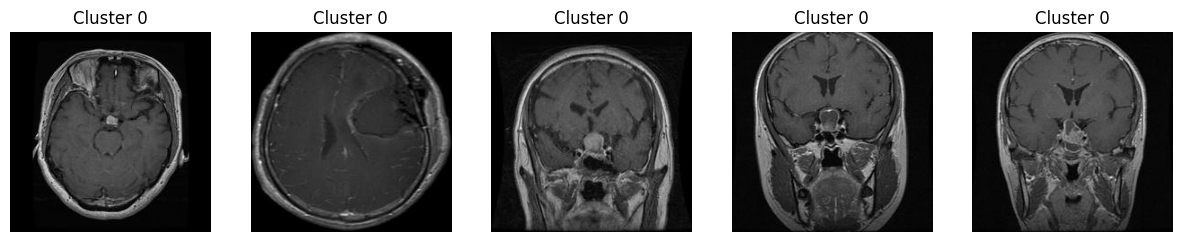

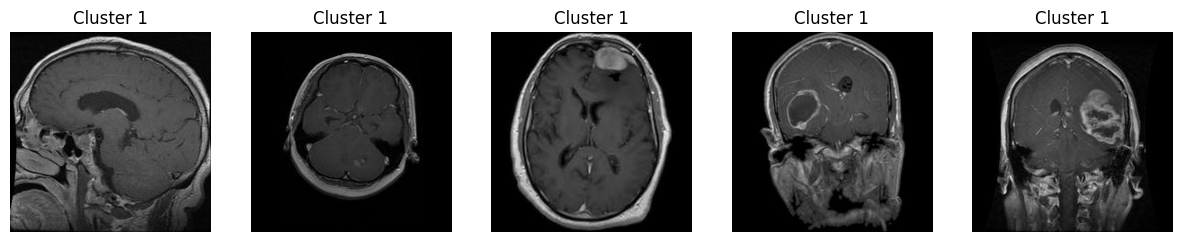

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Récupérer les chemins des images (assurez-vous que l'ordre correspond aux features)
img_paths = sorted((PREPARED_DIR / WITHOUT_LABEL).glob("*.jpg"))

# 2. Affichage rapide pour vérification
for cluster_id in [0, 1]:
    indices = np.where(y_pred_unlabeled == cluster_id)[0][:5] # 5 premières images
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, 5, i + 1)
        plt.imshow(Image.open(img_paths[idx]))
        plt.title(f"Cluster {cluster_id}")
        plt.axis('off')
    plt.show()

# 3. Inversion manuelle si nécessaire
# Si vous voyez que le Cluster 0 est le "Normal", décommentez la ligne suivante :
# y_pred_unlabeled = 1 - y_pred_unlabeled

In [3]:
# Inversion pour avoir Cancer = 1 et Normal = 0
y_pred_unlabeled = 1 - y_pred_unlabeled

print("Labels inversés avec succès :")
print(f"Nombre de cas 'Cancer' (Label 1) : {(y_pred_unlabeled == 1).sum()}")
print(f"Nombre de cas 'Normal' (Label 0) : {(y_pred_unlabeled == 0).sum()}")

# SAUVEGARDE DES LABELS FAIBLES
print("\nSauvegarde des labels faibles...")
method_suffix = "tsne" if USE_TSNE else "pca"
weak_labels_filename = f"weak_labels.npy"
np.save(FEATURES_DIR / weak_labels_filename, y_pred_unlabeled)
print(f"✓ Labels faibles sauvegardés: {weak_labels_filename}")

Labels inversés avec succès :
Nombre de cas 'Cancer' (Label 1) : 468
Nombre de cas 'Normal' (Label 0) : 938

Sauvegarde des labels faibles...
✓ Labels faibles sauvegardés: weak_labels.npy
